# NLP Mini Project: Traditional Text Classification Pipeline

## Project Overview

In this project, students will build a **complete traditional Natural Language Processing (NLP) machine learning pipeline** for text classification. The focus is on **classical NLP techniques** rather than deep learning.

Students will learn how to:

- Perform text preprocessing
- Apply classical NLP techniques
- Convert text into numerical features
- Train machine learning models
- Evaluate model performance
- Save preprocessing objects and trained models
- Deploy the trained model using a simple FastAPI service

---

## Learning Objectives

By completing this project, students will:

1. Understand the steps of a traditional NLP pipeline
2. Implement text preprocessing techniques
3. Convert text into vector representations (BOW / TF-IDF)
4. Train classical ML models for text classification
5. Evaluate models using proper metrics
6. Save preprocessing pipelines and models
7. Deploy the model as an API using FastAPI

---

# Dataset


### Kaggle Dataset (Optional)

Students may alternatively use an easy Kaggle dataset such as:

Spam Classification

https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

Task:

Classify SMS messages as:

- spam
- ham

---

# Project Requirements

Students must implement the following pipeline:

1. Data loading
2. Text preprocessing
3. Feature extraction
4. Model training
5. Model evaluation
6. Saving artifacts
7. API deployment

---

# Step 1 — Install Required Libraries

Students may need the following libraries:

- pandas
- numpy
- scikit-learn
- nltk
- spacy
- fastapi
- uvicorn
- joblib

Hint: Install missing libraries using pip.


In [1]:
!pip install pandas numpy scikit-learn nltk spacy fastapi uvicorn joblib


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Step 2 — Load Dataset

### Option A: Load the Kaggle dataset

Hint:

Your task:

- Load the dataset
- Convert it into a pandas DataFrame
- Inspect sample rows

Questions:

- How many documents are there?
- How many classes exist?


In [2]:
import pandas as pd

df = pd.read_csv(r"D:\DEPI\Technical\spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
df['Unnamed: 4'].value_counts()

Unnamed: 4
GNT:-)"                                                     2
 just Keep-in-touch\" gdeve.."                              1
 Never comfort me with a lie\" gud ni8 and sweet dreams"    1
 CALL 2MWEN IM BK FRMCLOUD 9! J X\""                        1
 one day these two will become FREINDS FOREVER!"            1
Name: count, dtype: int64

In [5]:
df.drop(columns='Unnamed: 4', inplace=True)
df.drop(columns='Unnamed: 3', inplace=True)
df.drop(columns='Unnamed: 2', inplace=True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.columns = ['classification', 'text']
df.head()

,classification,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df['classification'].value_counts()

classification
ham     4825
spam     747
Name: count, dtype: int64

# 5572 documents, 2 classes (imbalanced data)

# Step 3 — Text Preprocessing

Students must implement the following preprocessing steps:

### 1. Case Folding

Convert text to lowercase.

Example:

`"Hello World" → "hello world"`

---

### 2. Remove Punctuation and Numbers

Use **Regular Expressions (re)**.

Hint:

Use `re.sub()`.

---

### 3. Tokenization

Split text into tokens.

Example:

`"machine learning is fun" → ["machine","learning","is","fun"]`

---

### 4. Stopword Removal

Remove common words such as:

- the
- is
- and

Hint:

Use NLTK stopwords.

---

### 5. Stemming

Apply a stemming algorithm.

Example:

- running → run
- played → play

Hint:

Use `PorterStemmer`.

---

### 6. Lemmatization

Convert words to dictionary form.

Example:

- better → good
- running → run

Hint:

Use `WordNetLemmatizer`.

---

### Task

Create a **single preprocessing function** that performs all steps.


In [8]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [9]:
nltk.download('punkt')  # For word_tokenize
nltk.download('stopwords')  # For stopwords
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Omama\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Omama\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Omama\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [11]:
def process_text(text):

    text = text.lower()  #case folding

    text = re.sub(r'[^a-zA-Z\s]', '', text) #remove any non alphabetical character

    words = word_tokenize(text) #tokenization

    words = [word for word in words if word not in stop_words] #stop word removal

    words = [lemmatizer.lemmatize(word) for word in words] #lemmatization

    return " ".join(words)


In [12]:
nltk.download('punkt_tab')
df['processed_text'] = df['text'].apply(process_text)
df.head()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Omama\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,classification,text,processed_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [13]:
df['length'] = df['processed_text'].apply(len)
hamlen=df[df['classification']=='ham']['length']
spamlen=df[df['classification']=='spam']['length']

C:\Users\Omama\AppData\Local\Temp\ipykernel_8524\2987688281.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([hamlen, spamlen], labels=["Ham","Spam"])


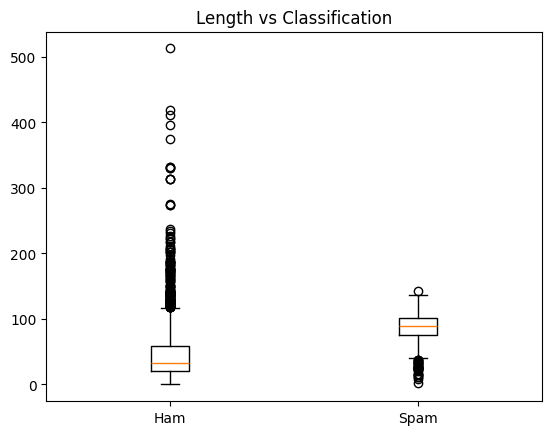

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.boxplot([hamlen, spamlen], labels=["Ham","Spam"])
plt.title("Length vs Classification")
plt.show()

# Step 4 — Feature Extraction

Convert text into numeric features.

Students must implement **two techniques**:

### 1. Bag of Words (BOW)

Hint:

`CountVectorizer`

---

### 2. TF-IDF

Hint:

`TfidfVectorizer`

---

Questions:

- What is the difference between BOW and TF-IDF?
- Which one performs better for your dataset?


In [15]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
X=df['processed_text']
y=df['classification']
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2,stratify=y, random_state=42)

In [16]:
bow_vectorizer = CountVectorizer()
tfidf_vectorizer = TfidfVectorizer()

X_train_bow=bow_vectorizer.fit_transform(X_train)
X_test_bow=bow_vectorizer.transform(X_test)

X_train_tfidf=tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf=tfidf_vectorizer.transform(X_test)

# Step 5 — Train Machine Learning Models

Students must train **at least two models**.

Recommended models:

- Logistic Regression
- Naive Bayes
- Linear SVM

Hints:

Split the dataset using:

`train_test_split`

Train models on:

- BOW features
- TF-IDF features


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

In [18]:
lr_bow=LogisticRegression()
lr_bow.fit(X_train_bow, y_train)

LogisticRegression()

In [19]:
y_pred_lrbow= lr_bow.predict(X_test_bow)

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [21]:
print("Logistic Regression BOW")
print("accuracy:", accuracy_score(y_test, y_pred_lrbow))
print(confusion_matrix(y_test, y_pred_lrbow))
print(classification_report(y_test, y_pred_lrbow))

Logistic Regression BOW
accuracy: 0.9838565022421525
[[966   0]
 [ 18 131]]
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       1.00      0.88      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [22]:
nb_bow=MultinomialNB()
nb_bow.fit(X_train_bow, y_train)

MultinomialNB()

In [23]:
y_pred_nbbow= nb_bow.predict(X_test_bow)

In [24]:

print("Naive Bayes BOW")
print("accuracy:", accuracy_score(y_test, y_pred_nbbow))
print(confusion_matrix(y_test, y_pred_nbbow))
print(classification_report(y_test, y_pred_nbbow))

Naive Bayes BOW
accuracy: 0.9802690582959641
[[961   5]
 [ 17 132]]
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       966
        spam       0.96      0.89      0.92       149

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [25]:
svm_bow=LinearSVC()
svm_bow.fit(X_train_bow, y_train)
y_pred_svmbow= svm_bow.predict(X_test_bow)

In [26]:
print("Linear SVM BOW")
print("accuracy:", accuracy_score(y_test, y_pred_svmbow))
print(confusion_matrix(y_test, y_pred_svmbow))
print(classification_report(y_test, y_pred_svmbow))

Linear SVM BOW
accuracy: 0.9856502242152466
[[966   0]
 [ 16 133]]
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       1.00      0.89      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



In [27]:
lr_tfidf=LogisticRegression()
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_lrtf= lr_tfidf.predict(X_test_tfidf)
print("Logistic Regression TF-IDF")
print("accuracy:", accuracy_score(y_test, y_pred_lrtf))
print(confusion_matrix(y_test, y_pred_lrtf))
print(classification_report(y_test, y_pred_lrtf))


Logistic Regression TF-IDF
accuracy: 0.9641255605381166
[[965   1]
 [ 39 110]]
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       0.99      0.74      0.85       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.96      0.96      1115



In [28]:
nb_tfidf=MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nbtf= nb_tfidf.predict(X_test_tfidf)
print("Naive Bayes TF-IDF")
print("accuracy:", accuracy_score(y_test, y_pred_nbtf))
print(confusion_matrix(y_test, y_pred_nbtf))
print(classification_report(y_test, y_pred_nbtf))

Naive Bayes TF-IDF
accuracy: 0.9632286995515695
[[965   1]
 [ 40 109]]
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       0.99      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [29]:
svm_tfidf=LinearSVC()
svm_tfidf.fit(X_train_tfidf, y_train)
y_pred_svmtf= svm_tfidf.predict(X_test_tfidf)
print("Linear SVM TF-IDF")
print("accuracy:", accuracy_score(y_test, y_pred_svmtf))
print(confusion_matrix(y_test, y_pred_svmtf))
print(classification_report(y_test, y_pred_svmtf))

Linear SVM TF-IDF
accuracy: 0.9838565022421525
[[965   1]
 [ 17 132]]
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



# Step 6 — Model Evaluation

Students must evaluate models using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

Hint:

Use:

`classification_report`

and

`confusion_matrix`

---

### Analysis Questions

Students must answer:

- Which model performed best?
- Did TF-IDF outperform BOW?
- Why might that happen?


Best overall accuracy: Linear SVM BOW (0.986) slightly beats the others.

Best spam recall: Linear SVM BOW, Naive Bayes BOW, and Linear SVM TF-IDF all have 0.89, which is the highest.

Best F1-score for spam: Linear SVM BOW and Linear SVM TF-IDF tie at 0.94.

# Step 7 — Save Preprocessing and Models

Students must save the following objects:

- text preprocessing pipeline
- vectorizer
- trained model

Use either:

- pickle
- joblib

Example files:

```
preprocessor.pkl
vectorizer.pkl
model.pkl
```

Hints:

Saving models allows reuse without retraining.


In [33]:
import joblib
joblib.dump(tfidf_vectorizer, "vectorizer.pkl")
joblib.dump(svm_tfidf, "model.pkl")
#joblib.dump(process_text, "preprocess.pkl")

['model.pkl']

# Step 8 — Build a FastAPI Model Service

Students will create a simple **prediction API**.

### Goal

Send text → receive predicted class.

---

## Project Structure

Suggested folder structure:

```
nlp_project
│
├── model.pkl
├── vectorizer.pkl
├── preprocess.pkl
│
├── app.py
└── notebook.ipynb
```

---

## FastAPI Implementation Hints

Steps:

1. Load saved objects
2. Create API endpoint
3. Accept input text
4. Apply preprocessing
5. Vectorize text
6. Predict label
7. Return prediction

---

### Example Endpoint

`POST /predict`

Input:

```
{
  "text": "Free money!!! Click this link"
}
```

Output:

```
{
  "prediction": "spam"
}
```

---

### Run the API

Students should run:

```
uvicorn app:app --reload
```

Then open:

http://127.0.0.1:8000/docs

to test the API using Swagger UI.


# Bonus Tasks (Optional)

Students can extend the project by:

- Creating a scikit-learn Pipeline
- Performing hyperparameter tuning
- Adding model comparison plots
- Deploying the API with Docker
- Building a simple Streamlit UI
